# <center>🩺 Symptom to Disease Prediction System</center>
---

## 📝 Introduction - A Multi-class Classification Problem

**Definition:**  
The **Symptom to Disease Prediction System** is a computational framework that predicts the most probable disease based on natural language descriptions of symptoms. It uses **Natural Language Processing (NLP)** techniques such as **TF-IDF vectorization** and **Machine Learning (ML)** models including **Naive Bayes, Logistic Regression, SVM, Random Forest, and XGBoost** to classify symptoms into one of 24 diseases.  

**Applications:**  
- Assist doctors in preliminary diagnosis  
- Support telemedicine platforms  
- Monitor patient-reported symptoms  
- Automate disease identification for healthcare research  

---

## 🖥️ Input & Output

**Input:** Natural language description of symptoms  
**Output:** Predicted Disease Label (e.g., Typhoid, Psoriasis, Dengue)

---

## 📊 Examples (Symptom Dataset)

| Sr. No | Symptom Description (Input)                     | Predicted Disease (Output)       |
|--------|-------------------------------------------------|---------------------------------|
| 1      | High fever, abdominal pain, and weakness       | Typhoid                         |
| 2      | Red, scaly, itchy skin patches                 | Psoriasis                        |
| 3      | Frequent urination and burning sensation      | Urinary Tract Infection          |
| 4      | Severe headache, nausea, and sensitivity to light | Migraine                     |
| 5      | Persistent cough and difficulty breathing     | Pneumonia                        |

---

## 👩‍💻 Developer and System Information

| Field                        | Details                                                                 |
|-------------------------------|-------------------------------------------------------------------------|
| **Developer Name**            |  Asfa Jabeen                                                     |
| **Supervisors**               | Asfa Jabeen; Dr. Rao Muhammad Adeel Nawab                                                       |
| **Program Name**              | Symptom2Disease_Prediction_System                                       |
| **IDE**                       | Jupyter Notebook / VS Code                                              |
| **Programming Language**      | Python 3.13.5                                                           |
| **Operating System**          | Windows 11                                            |
| **Libraries**                 | NumPy, Pandas, scikit-learn, NLTK, XGBoost, Flask, Pickle              |
| **Dataset**                   | Symptom2Disease.csv (1200 samples, 24 diseases)                         |
| **Date of Completion**        | 06-Dec-2025                                                             |
| **Email**                     | asfajabeen665@gmail.com                                                           |
| **LinkedIn (asfa)**           | https://www.linkedin.com/in/asfa-jabeen-068153290?utm_source=share&utm_campaign=share_via&utm_content=profile&utm_medium=android_app                                   |
| **LinkedIn (Dr. Adeel)**      | https://www.linkedin.com/in/rao-muhammad-adeel-nawab                        |


---

## 🔧 Workflow

- **Step 1:** Import Libraries  

- **Step 2:** Load Dataset (`Symptom2Disease.csv`)  
  - View columns  
  - Keep required columns (`text` and `label`)  

- **Step 3:** Data Cleaning and Preprocessing  
  - Download & set stopwords  
  - Write function to clean text (lowercase, remove numbers, punctuation, stopwords, lemmatization)  
  - Load dataset  
  - Handle missing values (drop NaNs) ✅  
  - Remove duplicates ✅  
  - Apply text cleaning function  
  - View cleaned data  
  - Save as `cleaned_data.csv`  

- **Step 4:** Encode Labels  
  - Convert disease labels to numeric IDs  
  - Save as `encoded_data.csv`  

- **Step 5:** Split Dataset  
  - Split into training & testing sets (e.g., 80:20)  

- **Step 6:** Feature Extraction (TF-IDF)  
  - Train TF-IDF vectorizer on training data  
  - Transform training & testing text into feature vectors  
  - Save TF-IDF vectorizer (`tfidf_vectorizer.pkl`)  

- **Step 7:** Model Training & Parameter Tuning  
  - Select ML algorithms: Naive Bayes, Logistic Regression, Linear SVM, Random Forest, XGBoost  
  - Define hyperparameter grid for each model  
  - Run GridSearchCV for each model  
  - Experiment with different TF-IDF **feature sizes** (2500, 3000, 3500, 4000, 4500)  
  - Experiment with **n-gram types** (word unigram, char 7-gram)  
  - Evaluate models using **F1-score / accuracy**  
  - Log all experiments to `experiment_results.csv`  
  - Select **best model**  
  - Save **best model** (`best_model.pkl`)  

- **Step 8:** Testing Phase  
  - Load best model (`best_model.pkl`)  
  - Evaluate on testing data  
  - Display metrics: Accuracy, F1-score, Confusion Matrix, Classification Report  

- **Step 9:** Application Phase (Flask GUI)  
  - Load TF-IDF vectorizer and best model  
  - Take input from user (symptoms)  
  - Clean & preprocess input (same as training)  
  - Transform input using TF-IDF  
  - Predict disease using trained model  
  - Return prediction to user  
---

## Data - Download Link
##### [Symptom2Disease Dataset](https://www.kaggle.com/datasets/niyarrbarman/symptom2disease)

## Code – Symptom to diseases prediction system


In [22]:
# === Step 1: Import Libraries ===
import pandas as pd
import numpy as np
import re, string, pickle
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import nltk
import joblib

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asfa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asfa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load dataset

In [13]:
df = pd.read_csv('Symptom2Disease.csv')
df = df[['text','label']]
print("Original dataset: ", df.shape)
df.head()

Original dataset:  (1200, 2)


,text,label
0,I have been experiencing a skin rash on my arm...,Psoriasis
1,"My skin has been peeling, especially on my kne...",Psoriasis
2,I have been experiencing joint pain in my fing...,Psoriasis
3,"There is a silver like dusting on my skin, esp...",Psoriasis
4,"My nails have small dents or pits in them, and...",Psoriasis


## Data Cleaning and Preprocessing 

In [14]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df = df.dropna(subset=['text','label']).drop_duplicates(subset=['text','label']).reset_index(drop=True)
df['cleaned_text'] = df['text'].apply(clean_text)
df.to_csv("cleaned_data.csv", index=False)



## Label Encoding

In [15]:
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])
df.to_csv("encoded_data.csv", index=False)
df = df[['cleaned_text', 'encoded_label']]
df.to_csv("cleaned_encoded.csv", index=False)
print(df.head())


                                        cleaned_text  encoded_label
0  experiencing skin rash arm leg torso past week...             15
1  skin peeling especially knee elbow scalp peeli...             15
2  experiencing joint pain finger wrist knee pain...             15
3  silver like dusting skin especially lower back...             15
4  nail small dent pit often feel inflammatory te...             15


In [16]:
print(len(df))
df.columns

1153


Index(['cleaned_text', 'encoded_label'], dtype='object')

In [17]:
df = df.dropna(subset=['cleaned_text', 'encoded_label'])
print(len(df))


1153


## Split Dataset

In [18]:
X = df['cleaned_text']
y = df['encoded_label']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(len(X_train))
print(len(X_test))

X_train

922
231


874     stomach hurt frequently acquire temperature ex...
664     work started feeling headache chest pain dizzi...
43      finger sol pretty thick skin cracked severely ...
478     bowel motion giving lot problem right going di...
378     day ive nasty cough cold sinus clogged facial ...
                              ...                        
1043    longer want sex difficult regularly brain fog ...
71      recently calf cramping frequently especially w...
737     suffering back pain productive cough weakness ...
346     body itching terribly red spot everywhere patc...
775     ive felt really scratchy nauseated worn also h...
Name: cleaned_text, Length: 922, dtype: object

## Feature Extraction

In [19]:
vectorizer = TfidfVectorizer(
    max_features=5000,   
    ngram_range=(1, 2), 
    stop_words='english'
)

# Fit TF-IDF on training data
vectorizer.fit(X_train)

# Transform training data
X_train_tfidf = vectorizer.transform(X_train)
X_train_tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)
X_train_tfidf_df = X_train_tfidf_df.round(2)  # round values for display

print("\nTF-IDF Features for Training Data (first 5 rows):")
print(X_train_tfidf_df.head())

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)
X_test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)
X_test_tfidf_df = X_test_tfidf_df.round(2)

print("\nTF-IDF Features for Test Data (first 5 rows):")
print(X_test_tfidf_df.head())

# Save TF-IDF vectorizer for later use
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("\n✅ TF-IDF vectorizer saved successfully!")


TF-IDF Features for Training Data (first 5 rows):
   abdomen  abdomen day  abdomen felt  abdomen frequently  abdomen hour  \
0      0.0          0.0           0.0                 0.0           0.0   
1      0.0          0.0           0.0                 0.0           0.0   
2      0.0          0.0           0.0                 0.0           0.0   
3      0.0          0.0           0.0                 0.0           0.0   
4      0.0          0.0           0.0                 0.0           0.0   

   abdomen hurt  abdomen indigestion  abdomen itchy  abdomen ofetn  \
0           0.0                  0.0            0.0            0.0   
1           0.0                  0.0            0.0            0.0   
2           0.0                  0.0            0.0            0.0   
3           0.0                  0.0            0.0            0.0   
4           0.0                  0.0            0.0            0.0   

   abdomen really  ...  yellow ive  yellow ooze  yellow rash  \
0            

## Train and Save Best Model for Symptom2Disease

In [20]:
best_model = SVC(
    C=10,
    kernel='linear',
    probability=True   # Optional: needed if you want predict_proba
)

best_model.fit(X_train_tfidf, y_train)

,C,10
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
joblib.dump(best_model, "best_model_svm.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\n✅ Best SVM model and TF-IDF vectorizer saved successfully!")


✅ Best SVM model and TF-IDF vectorizer saved successfully!


In [24]:
# ----------------------------
# Load saved model and TF-IDF vectorizer
# ----------------------------
loaded_model = joblib.load('best_model_svm.pkl')        # Your trained SVM model
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl') # Saved TF-IDF vectorizer
print("Model and vectorizer loaded successfully!")

# ----------------------------
# Transform test data using loaded TF-IDF vectorizer
# ----------------------------
X_test_tfidf_loaded = loaded_vectorizer.transform(X_test)

# ----------------------------
# Predict using the loaded model
# ----------------------------
y_pred_loaded = loaded_model.predict(X_test_tfidf_loaded)

# ----------------------------
# Evaluate the loaded model
# ----------------------------
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
report_loaded = classification_report(y_test, y_pred_loaded)

print(f"\nTest Accuracy: {accuracy_loaded:.4f}")
print("\nClassification Report:")
print(report_loaded)

Model and vectorizer loaded successfully!

Test Accuracy: 0.9697

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      0.90      0.95        10
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00        10
           9       0.91      1.00      0.95        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00         8
          12       1.00      1.00      1.00         9
          13       1.00      1.00      1.00         9
          14       1.00      1.00      1.00         9
          15       1.00      0.90      0.95   

## Display Evaluation Metrics and Confusion Matrix



Evaluation Metrics:


,Accuracy,Precision,Recall,F1-Score
0,0.969697,0.972889,0.969697,0.969526



Confusion Matrix Table:


,Predicted 0,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5,Predicted 6,Predicted 7,Predicted 8,Predicted 9,...,Predicted 14,Predicted 15,Predicted 16,Predicted 17,Predicted 18,Predicted 19,Predicted 20,Predicted 21,Predicted 22,Predicted 23
Actual 0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Actual 1,0,9,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Actual 2,0,0,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Actual 3,0,0,0,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Actual 4,0,0,0,0,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Actual 5,0,0,0,0,0,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Actual 6,0,0,0,0,0,0,9,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Actual 7,0,0,0,0,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
Actual 8,0,0,0,0,0,0,0,0,10,0,...,0,0,0,0,0,0,0,0,0,0
Actual 9,0,0,0,0,0,0,0,0,0,10,...,0,0,0,0,0,0,0,0,0,0


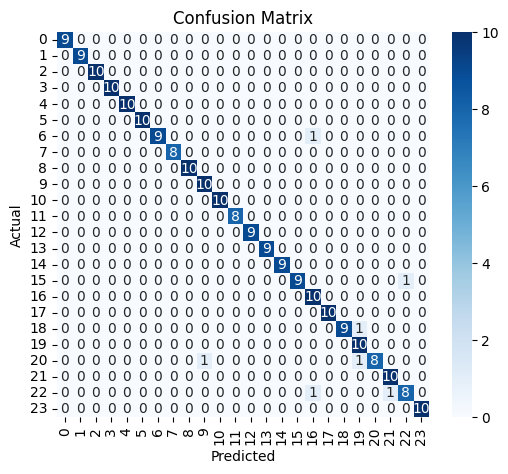

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Compute Evaluation Metrics ---
accuracy  = accuracy_score(y_test, y_pred_loaded)
precision = precision_score(y_test, y_pred_loaded, average='weighted')
recall    = recall_score(y_test, y_pred_loaded, average='weighted')
f1        = f1_score(y_test, y_pred_loaded, average='weighted')

# Combine metrics into a DataFrame
metrics_df = pd.DataFrame({
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
})

print("\nEvaluation Metrics:")
display(metrics_df)

# --- Confusion Matrix ---
conf_matrix = confusion_matrix(y_test, y_pred_loaded)

# Automatically get class labels
classes = sorted(np.unique(y_test))

# Create DataFrame with correct shape
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f'Actual {c}' for c in classes],
    columns=[f'Predicted {c}' for c in classes]
)

print("\nConfusion Matrix Table:")
display(conf_matrix_df)

# --- Plot Confusion Matrix as Heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'{c}' for c in classes],
    yticklabels=[f'{c}' for c in classes]
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
